# MakeMore — Part 1: Bigram Language Model

**Based on:** Andrej Karpathy's "The spelled-out intro to language modeling: building makemore"  

## Overview

In this notebook we build the simplest possible language model: a **bigram model**.  
A bigram model predicts the next character using only the single previous character.  
We implement it in **two ways**:

1. **Statistical approach** — count bigram frequencies, normalize to get probabilities.
2. **Neural network approach** — single linear layer (one-hot → logits → softmax) trained via gradient descent.

Both approaches converge to the same solution, which is a key insight of this part.

**MLflow** is used to track hyperparameters, losses, and generated samples across training runs.

---

## 1. Setup

In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch

%matplotlib inline

# Deterministic seed for reproducibility
SEED = 2147483647
g = torch.Generator().manual_seed(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"MLflow  version : {mlflow.__version__}")

PyTorch version : 2.11.0+cu128
MLflow  version : 3.11.1


In [16]:
# ── Device Setup ──────────────────────────────────────────────────────────────
# Automatically use GPU if available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
  GPU : NVIDIA GeForce RTX 5080 Laptop GPU
  VRAM: 16.6 GB


In [17]:
# Configure MLflow experiment
EXPERIMENT_NAME = "makemore-part1-bigrams"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow experiment: '{EXPERIMENT_NAME}'")

MLflow experiment: 'makemore-part1-bigrams'


## 2. Data Loading & Exploration

In [18]:
# Load the names dataset
with open('data/names.txt', 'r') as f:
    words = f.read().splitlines()

print(f"Total words  : {len(words):,}")
print(f"Shortest name: {min(len(w) for w in words)} chars")
print(f"Longest name : {max(len(w) for w in words)} chars")
print(f"Sample names : {words[:10]}")

Total words  : 32,033
Shortest name: 2 chars
Longest name : 15 chars
Sample names : ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [19]:
# Build the character vocabulary
# '.' is used as the special start/end token (index 0)
chars = sorted(set(''.join(words)))
stoi = {s: i + 1 for i, s in enumerate(chars)}  # char  → index
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}           # index → char

VOCAB_SIZE = len(itos)  # 27: a-z plus '.'
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Vocabulary     : {itos}")

Vocabulary size: 27
Vocabulary     : {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 3. Statistical Bigram Model

### 3.1 Build the Bigram Count Matrix `N`

We count every pair of consecutive characters `(ch1, ch2)` across the entire dataset.  
`N[i, j]` = number of times character `j` follows character `i`.

In [20]:
# Build the bigram count matrix N  (shape: 27 × 27)
N = torch.zeros((VOCAB_SIZE, VOCAB_SIZE), dtype=torch.int32)

for word in words:
    chars_seq = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chars_seq, chars_seq[1:]):
        N[stoi[ch1], stoi[ch2]] += 1

print(f"Count matrix shape: {N.shape}")
print(f"Total bigrams     : {N.sum().item():,}")

Count matrix shape: torch.Size([27, 27])
Total bigrams     : 228,146


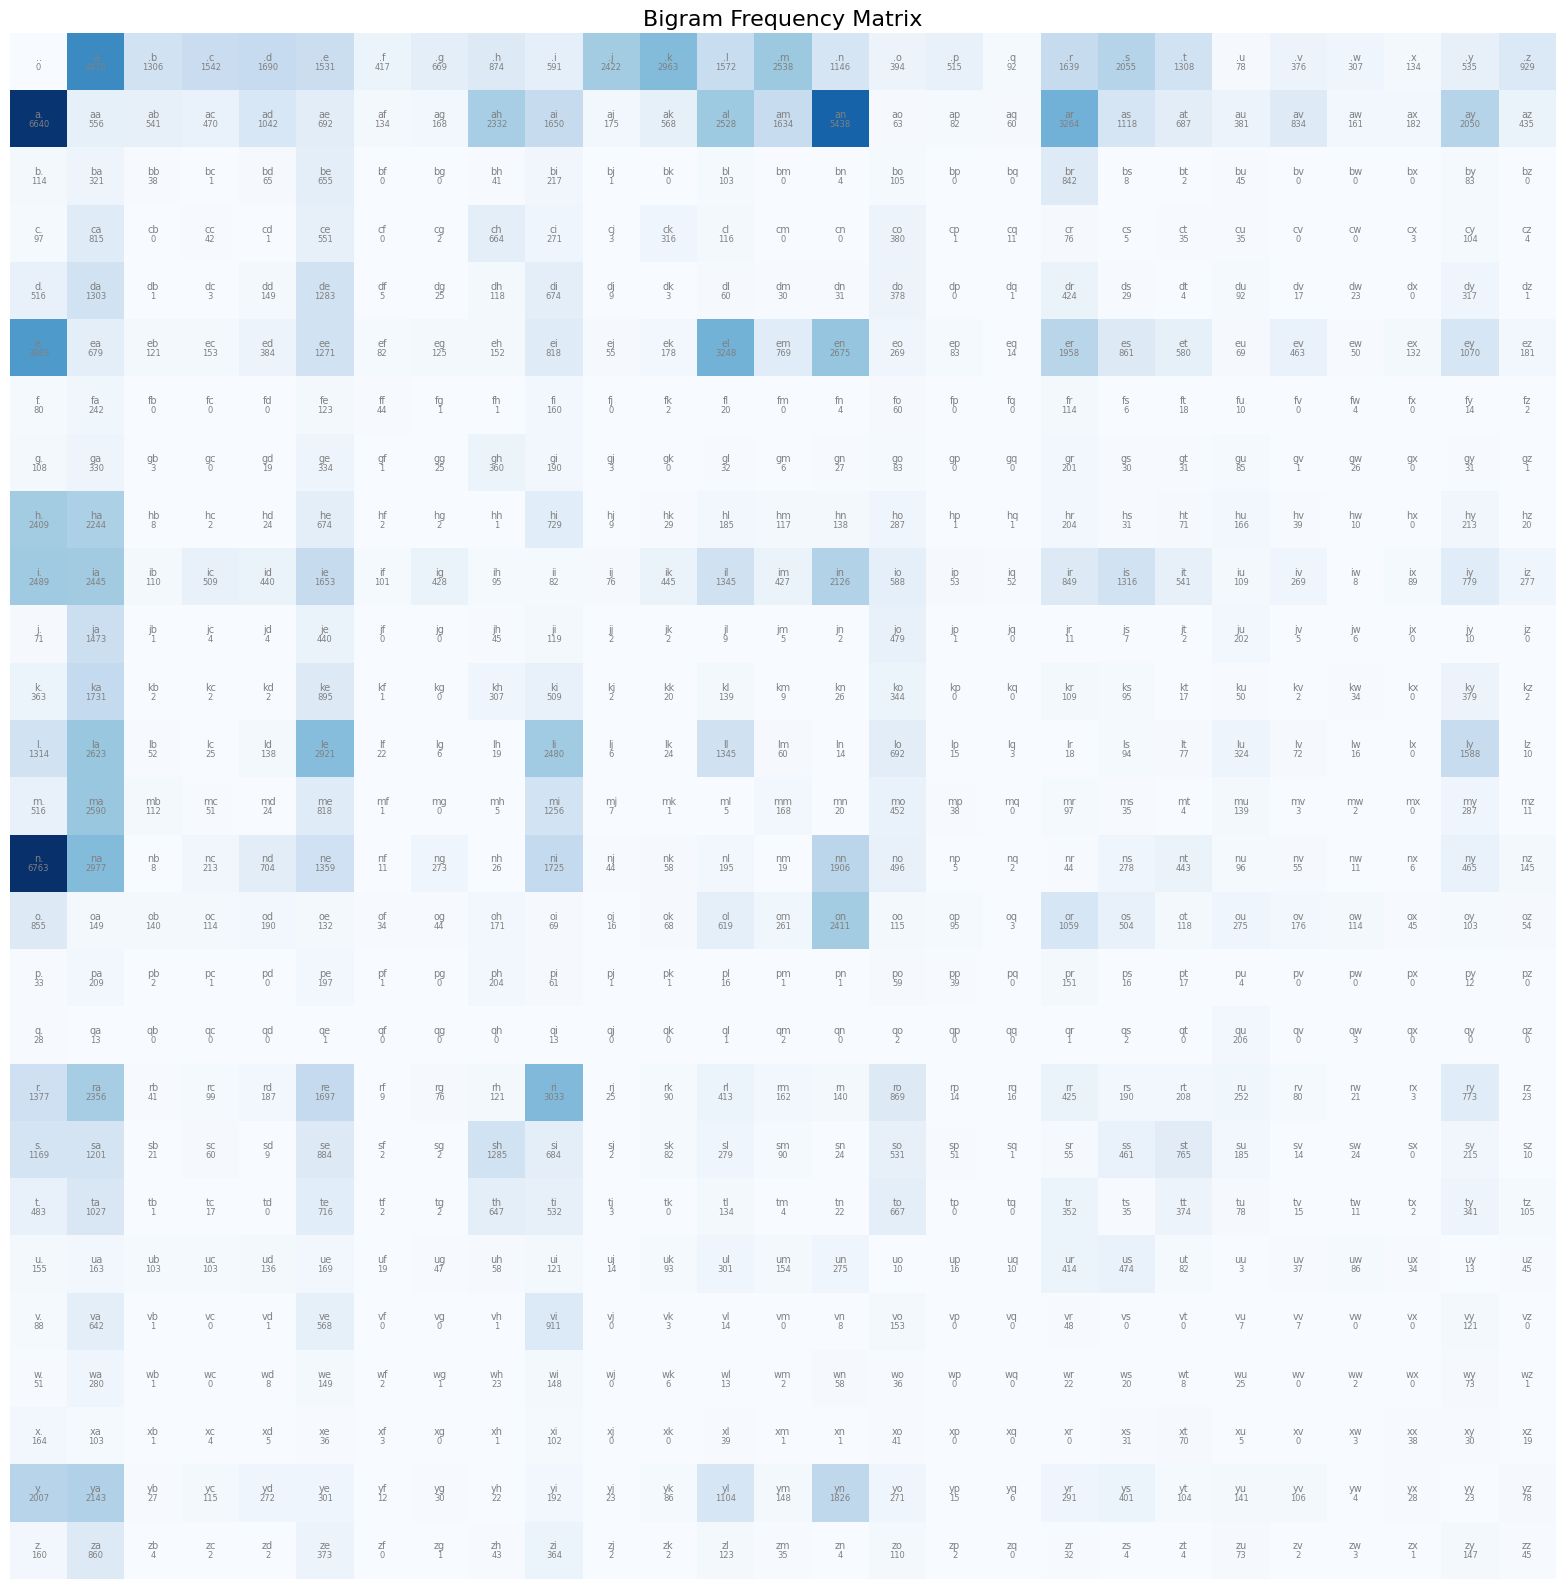

In [21]:
# Visualize the bigram count matrix
fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(N, cmap='Blues')

for i in range(VOCAB_SIZE):
    for j in range(VOCAB_SIZE):
        label = itos[i] + itos[j]
        ax.text(j, i, label,  ha='center', va='bottom', color='gray', fontsize=7)
        ax.text(j, i, N[i, j].item(), ha='center', va='top',    color='gray', fontsize=6)

ax.axis('off')
ax.set_title('Bigram Frequency Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('bigram_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.2 Convert Counts to Probabilities (Laplace Smoothing)

We add a smoothing constant of **1** to every count (Laplace / add-one smoothing).  
This avoids zero probabilities for unseen bigrams and acts as a form of regularization.

In [22]:
# Convert counts to row-normalized probabilities with Laplace smoothing
# P[i, j] = P(next char = j | current char = i)
# Move to GPU for fast matrix operations
P = (N + 1).float().to(device)              # add-one smoothing, on device
P /= P.sum(dim=1, keepdim=True)             # normalize each row

print(f"Probability matrix shape : {P.shape}")
print(f"Matrix device            : {P.device}")
print(f"Row 0 (starts from '.') sums to: {P[0].sum().item():.6f}")


Probability matrix shape : torch.Size([27, 27])
Matrix device            : cuda:0
Row 0 (starts from '.') sums to: 1.000000


### 3.3 Sample Names from the Statistical Model

In [23]:
def sample_from_model(P: torch.Tensor, itos: dict, num_samples: int = 10,
                      seed: int = SEED) -> list[str]:
    """Sample `num_samples` names by autoregressively drawing from the bigram
    probability matrix P.
    Note: torch.multinomial with a seeded Generator requires the tensor on CPU.
    """
    gen   = torch.Generator().manual_seed(seed)
    P_cpu = P.cpu()   # move to CPU for seeded sampling
    samples = []
    for _ in range(num_samples):
        out, ix = [], 0
        while True:
            ix = torch.multinomial(P_cpu[ix], num_samples=1,
                                   replacement=True, generator=gen).item()
            if ix == 0:
                break
            out.append(itos[ix])
        samples.append(''.join(out))
    return samples


stat_samples = sample_from_model(P, itos, num_samples=10)
print("Samples from statistical bigram model:")
for name in stat_samples:
    print(f"  {name}")


Samples from statistical bigram model:
  cexze
  momasurailezitynn
  konimittain
  llayn
  ka
  da
  staiyaubrtthrigotai
  moliellavo
  ke
  teda


### 3.4 Evaluate: Negative Log-Likelihood (NLL)

The **negative log-likelihood** measures how surprised the model is on average.  
Lower is better. An NLL of 0 would mean the model predicts perfectly.

In [24]:
def compute_nll(words: list[str], P: torch.Tensor, stoi: dict) -> float:
    """Compute the average negative log-likelihood of the bigram probability
    matrix P over the entire word list. Works with P on any device."""
    P_cpu = P.cpu()   # ensure CPU for item-by-item indexing
    log_likelihood, n = 0.0, 0
    for word in words:
        chars_seq = ['.'] + list(word) + ['.']
        for ch1, ch2 in zip(chars_seq, chars_seq[1:]):
            log_likelihood += torch.log(P_cpu[stoi[ch1], stoi[ch2]]).item()
            n += 1
    return -log_likelihood / n


stat_nll = compute_nll(words, P, stoi)
print(f"Statistical model NLL: {stat_nll:.4f}")


Statistical model NLL: 2.4546


---
## 4. Neural Network Bigram Model

We implement the exact same model using a **single linear layer**:

```
one-hot(x)  →  logits = x @ W  →  softmax  →  probs
```

Training via gradient descent on the cross-entropy loss (= negative log-likelihood)  
converges to the same probabilities as the statistical model.

### 4.1 Build the Training Dataset

In [25]:
# Build the full dataset of (input_char_index, target_char_index) pairs
# and move tensors to the GPU
xs, ys = [], []
for word in words:
    chars_seq = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chars_seq, chars_seq[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs).to(device)   # shape: (N,) — on GPU
ys = torch.tensor(ys).to(device)   # shape: (N,) — on GPU
NUM_EXAMPLES = xs.nelement()
print(f"Training examples : {NUM_EXAMPLES:,}")
print(f"Data device       : {xs.device}")


Training examples : 228,146
Data device       : cuda:0


### 4.2 Training Loop with MLflow Tracking

Hyperparameters we will track:
- `learning_rate`  
- `num_steps`  
- `reg_strength` — L2 regularization on weights (corresponds to Laplace smoothing)

In [29]:
def train_bigram_nn(
    xs: torch.Tensor,
    ys: torch.Tensor,
    vocab_size: int,
    learning_rate: float = 50.0,
    num_steps: int = 200,
    reg_strength: float = 0.01,
    seed: int = SEED,
) -> tuple[torch.Tensor, list[float]]:
    """Train a single-layer neural bigram model and return (weights W, loss history).
    xs and ys must already be on the target device.
    """
    # Create W on CPU with the seeded generator, then move to the target device.
    # torch.randn does not allow mixing a CPU generator with device='cuda'.
    gen = torch.Generator().manual_seed(seed)
    W = torch.randn((vocab_size, vocab_size), generator=gen).to(xs.device)
    W.requires_grad = True
    loss_history = []

    for step in range(num_steps):
        # ── Forward pass ─────────────────────────────────────────────────────
        xenc   = F.one_hot(xs, num_classes=vocab_size).float()  # (N, 27) on device
        logits = xenc @ W                                        # (N, 27)
        probs  = F.softmax(logits, dim=1)                        # (N, 27)

        # Cross-entropy loss + L2 regularization
        loss = -probs[torch.arange(xs.shape[0], device=xs.device), ys].log().mean()
        loss = loss + reg_strength * (W ** 2).mean()

        loss_history.append(loss.item())

        # ── Backward pass ────────────────────────────────────────────────────
        W.grad = None
        loss.backward()

        # ── Parameter update (gradient descent) ──────────────────────────────
        with torch.no_grad():
            W -= learning_rate * W.grad

    return W.detach(), loss_history


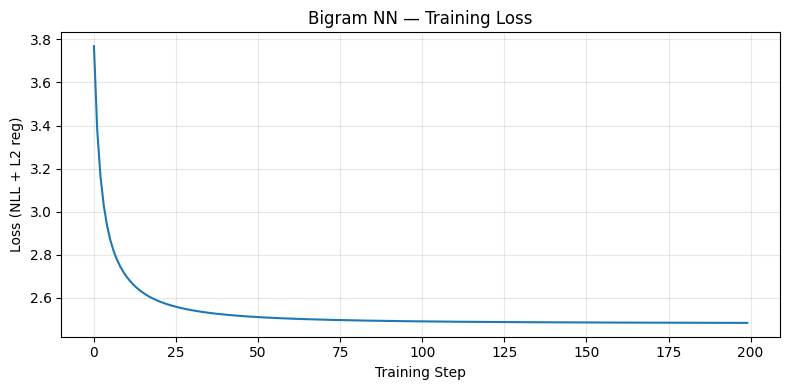


Final NN training loss : 2.4830
Statistical model NLL  : 2.4546
Device used            : cuda

Generated names (NN model):
  cexze
  momasurailezityha
  konimittain
  llayn
  ka
  da
  staiyaubrtthrigotai
  moliellavo
  ke
  teda
  ka
  emimmsade
  enkaviyny
  fobspehinivenvtahlasu
  dsor
  br
  jol
  pyawaisan
  ja
  fdinee


In [30]:
# ── Training run tracked by MLflow ────────────────────────────────────────────
LR           = 50.0
NUM_STEPS    = 200
REG_STRENGTH = 0.01

with mlflow.start_run(run_name="bigram-nn-baseline"):

    # — Log hyperparameters (including device) —
    mlflow.log_params({
        "model"        : "bigram-neural-network",
        "vocab_size"   : VOCAB_SIZE,
        "learning_rate": LR,
        "num_steps"    : NUM_STEPS,
        "reg_strength" : REG_STRENGTH,
        "seed"         : SEED,
        "device"       : str(device),
    })

    # — Train the model (W lives on GPU) —
    W, loss_history = train_bigram_nn(
        xs, ys,
        vocab_size=VOCAB_SIZE,
        learning_rate=LR,
        num_steps=NUM_STEPS,
        reg_strength=REG_STRENGTH,
    )

    # — Log loss at every step —
    for step, loss_val in enumerate(loss_history):
        mlflow.log_metric("train_loss", loss_val, step=step)

    final_loss = loss_history[-1]
    mlflow.log_metric("final_train_loss", final_loss)

    # — Plot and log the loss curve —
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(loss_history)
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss (NLL + L2 reg)')
    ax.set_title('Bigram NN — Training Loss')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('bigram_nn_loss.png', dpi=100)
    mlflow.log_artifact('bigram_nn_loss.png')
    plt.show()

    # — Generate sample names (sampling requires CPU) —
    def sample_from_nn(W: torch.Tensor, itos: dict, num_samples: int = 10,
                       seed: int = SEED) -> list[str]:
        """Sample names autoregressively from the trained NN weights."""
        gen   = torch.Generator().manual_seed(seed)
        W_cpu = W.cpu()   # move to CPU — seeded multinomial requires CPU
        samples = []
        for _ in range(num_samples):
            out, ix = [], 0
            while True:
                xenc   = F.one_hot(torch.tensor([ix]), num_classes=VOCAB_SIZE).float()
                logits = xenc @ W_cpu
                probs  = F.softmax(logits, dim=1)
                ix = torch.multinomial(probs, num_samples=1, replacement=True,
                                       generator=gen).item()
                if ix == 0:
                    break
                out.append(itos[ix])
            samples.append(''.join(out))
        return samples

    nn_samples = sample_from_nn(W, itos, num_samples=20)

    with open('bigram_nn_samples.txt', 'w') as f:
        f.write("Generated names (bigram NN model):\n")
        f.write('\n'.join(nn_samples))
    mlflow.log_artifact('bigram_nn_samples.txt')

    mlflow.log_metric("stat_model_nll", stat_nll)

    print(f"\nFinal NN training loss : {final_loss:.4f}")
    print(f"Statistical model NLL  : {stat_nll:.4f}")
    print(f"Device used            : {device}")
    print("\nGenerated names (NN model):")
    for name in nn_samples:
        print(f"  {name}")


---
## 5. Comparing Statistical vs. Neural Network Models

In [ ]:
# Convert NN weights to row-normalized probability matrix for direct comparison
# W is on GPU — move to CPU before passing to compute_nll
P_nn = F.softmax(W.cpu(), dim=1)

nn_nll = compute_nll(words, P_nn, stoi)

print("─" * 40)
print(f"{'Model':<30} {'NLL':>8}")
print("─" * 40)
print(f"{'Statistical (smoothed)':<30} {stat_nll:>8.4f}")
print(f"{'Neural Network':<30} {nn_nll:>8.4f}")
print("─" * 40)
print()
print("Key insight: when regularization → 0, the NN converges to the")
print("exact same solution as the statistical count model.")


────────────────────────────────────────
Model                               NLL
────────────────────────────────────────
Statistical (smoothed)           2.4546
Neural Network                   2.4653
────────────────────────────────────────

Key insight: when regularization → 0, the NN converges to the
exact same solution as the statistical count model.


---
## 6. Hyperparameter Experiment with MLflow

We sweep over two hyperparameters — `learning_rate` and `reg_strength` — and log every run.

In [ ]:
sweep_config = [
    {"learning_rate": 10.0,  "reg_strength": 0.001, "num_steps": 300},
    {"learning_rate": 50.0,  "reg_strength": 0.001, "num_steps": 300},
    {"learning_rate": 50.0,  "reg_strength": 0.01,  "num_steps": 300},
    {"learning_rate": 50.0,  "reg_strength": 0.1,   "num_steps": 300},
    {"learning_rate": 100.0, "reg_strength": 0.01,  "num_steps": 300},
]

sweep_results = []

for cfg in sweep_config:
    run_name = f"lr={cfg['learning_rate']}_reg={cfg['reg_strength']}"
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            "model"        : "bigram-neural-network",
            "vocab_size"   : VOCAB_SIZE,
            "learning_rate": cfg["learning_rate"],
            "num_steps"    : cfg["num_steps"],
            "reg_strength" : cfg["reg_strength"],
            "seed"         : SEED,
            "device"       : str(device),
        })

        W_run, hist = train_bigram_nn(
            xs, ys,
            vocab_size=VOCAB_SIZE,
            learning_rate=cfg["learning_rate"],
            num_steps=cfg["num_steps"],
            reg_strength=cfg["reg_strength"],
        )

        for step, lv in enumerate(hist):
            mlflow.log_metric("train_loss", lv, step=step)

        mlflow.log_metric("final_train_loss", hist[-1])
        sweep_results.append({**cfg, "final_loss": hist[-1]})

    print(f"{run_name:<40} final loss = {hist[-1]:.4f}")

print("\nBest configuration:")
best = min(sweep_results, key=lambda r: r["final_loss"])
print(best)


lr=10.0_reg=0.001                        final loss = 2.4901
lr=50.0_reg=0.001                        final loss = 2.4619
lr=50.0_reg=0.01                         final loss = 2.4815
lr=50.0_reg=0.1                          final loss = 2.5864
lr=100.0_reg=0.01                        final loss = 2.5044

Best configuration:
{'learning_rate': 50.0, 'reg_strength': 0.001, 'num_steps': 300, 'final_loss': 2.4618821144104004}


---
## 7. Summary

| Concept | Key Takeaway |
|---|---|
| **Bigram model** | Predict the next token using only the immediately preceding token |
| **Statistical approach** | Count bigrams, normalize to probabilities; simple and interpretable |
| **Neural NN approach** | Single linear layer trained with gradient descent |
| **Equivalence** | Both converge to the same solution when `reg_strength → 0` |
| **Laplace smoothing** | Adding 1 to counts ↔ L2 regularization on network weights |
| **NLL loss** | Measures model "surprise"; minimizing it maximizes the likelihood |
| **MLflow** | Tracks hyperparameters, metrics, and artifacts for every run |

**Next:** Part 2 — MLP with character embeddings and a larger context window.